## 1. Imports
Import all required libraries for deep learning (PyTorch), image processing (PIL, torchvision), data splitting (sklearn), and visualization (matplotlib).

use **environment_resnet.yml** to install all packages in your conda environment

In [18]:
import numpy as np
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
import torchvision.models as models
from torchvision.datasets import ImageFolder
import os
import shutil
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from PIL import Image

## 2. Data Transformation
Resize all images to 224×224 pixels and convert them to tensors with pixel values scaled to [0, 1], matching ResNet-50's expected input format.

In [19]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize the images to 224x224 pixels
    transforms.ToTensor(),
])

# Normalize pixel values to be between 0 and 1
# The normalization is done by the transforms.ToTensor()

## 3. Custom Dataset Class (`CancerDataset`)
Defines a custom PyTorch Dataset that accepts image file paths and labels, loads each image as RGB, and applies the defined transforms on access.

In [20]:
class CancerDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

## 4. Collect Image Paths & Labels
Scans all subfolders in `./data`. Folders are sorted alphabetically; images in the last folder (`TUM`) are labeled 1 (tumor), all others are labeled 0.

In [21]:
# Summon all images and give them a label (0 or 1) depending on the folder they are in
data_dir = './data'
all_images = []
all_labels = []

folders = sorted(os.listdir(data_dir)) # Sort the folders to ensure consistent labeling (TUM should be last)
for idx, folder in enumerate(folders):
    folder_path = os.path.join(data_dir, folder)
    if not os.path.isdir(folder_path):
        continue
    for img in os.listdir(folder_path):
        all_images.append(os.path.join(folder_path, img))
        # last folder is TUM, so label it as 1, otherwise label it as 0
        all_labels.append(1 if idx == len(folders)-1 else 0)

## 5. Train/Test Split
Splits data 80/20 into training and test sets using stratified sampling to preserve class distribution in both splits.

In [22]:
# Train/Test Split
train_images, test_images, train_labels, test_labels = train_test_split(
    all_images, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)
# Print the size of the train and test datasets
print("Size of the training set: ", len(train_images))
print("Size of the test set: ", len(test_images))

Size of the training set:  720
Size of the test set:  180


## 6. Create DataLoaders
Wraps the train and test datasets into PyTorch DataLoaders with batch size 32. Training data is shuffled each epoch; test data is not.

In [23]:
trainset = CancerDataset(train_images, train_labels, transform=transform)
testset = CancerDataset(test_images, test_labels, transform=transform)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

## 7. Sample Image Visualization
Displays one image from the first training batch to verify data loading. The tensor is transposed from PyTorch's CHW format to HWC for matplotlib.

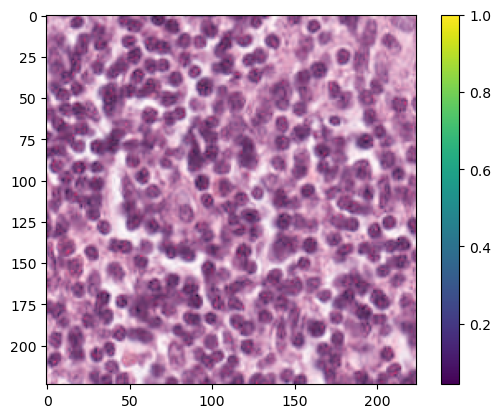

In [24]:
# In PyTorch, images are represented as (C, H, W), 
# we need to change it to (H, W, C) for visualization
train_images, train_labels = next(iter(trainloader))
train_images = train_images[0].numpy().transpose((1, 2, 0))

plt.figure()
plt.imshow(train_images)
plt.colorbar()
plt.grid(False)
plt.show()

## 8. Model Architecture – ResNet-50 (Transfer Learning)
Loads a pretrained ResNet-50 and freezes all layers except `layer4` and the final fully connected layer, which is replaced with a 2-class output head. Only these layers are updated during training.

#### **ResNet-50 Architecture:**
##### 01. **Conv2d** - Apply 64 different 7×7 filters (stride=2) to the input image, each producing a different feature map at half resolution. *--> extracts low-level features form raw pixels*
##### 02. **BatchNorm2d** - Normalizes every channel to mean = 0, vartiance = 1 *--> stabalizes trainigng in preventing from exploding/vanishing*
##### 03. **ReLu** - Kills all negative values *--> adds non-linearity, without the whole network would collapse to a single linear function*
##### 04. **MaxPool** - Downsamples features size from [batch, 64, 112, 112] to [batch, 64, 56, 56] *--> reduces computation for all following layers*
#### **Bottleneck-Layers**
##### 05. **Layer 1** - Recognizes simple textures e.g. cell walls, cell nucleus' *--> Resolution stays, channels grow [batch, **64-->256**, 56, 56]*
##### 06. **Layer 2** - Recognizes patterns e.g. cell grouping, tissue structure *--> Resolution halved, channels doubled [batch, **256-->512**, **56-->28**, **56-->28**]*
##### 07. **Layer 3** - Recognizes complexe structures e.g. abnormal cell clusters, irregular cell size (typical for tumor) *--> SResolution halved, channels doubled [batch, **512-->1024**, **28-->14**, **28-->14**]*
##### 08. **Layer 4** - Recognizes highly abstract features e.g. "this pattern looks like a tumor tissue" *--> Resolution halved, channels doubled [batch, **1024-->2048**, **14-->7**, **14-->7**]*
#### We now have 2048 feature maps of size 7x7
##### 09. **AdaptiveAvgPool2d** - Average each map to one number *--> makes output size independent of input resolution [batch, 2048, 1, 1]*
##### 10. **Flatten** - Reshape to a vector *--> Fully connected Layer expects a 1D input [batch, 2048]*
##### 11. **FC-Layer** - Matrix multiply *--> 2048-->2 this to numbers are the class scores (cancer/no-cancer)*


In [25]:
# =============================================================================
# Model
# =============================================================================

base_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Disable gradient updates for the earlier layers
# Freeze all layers except the last one in the base model
for param in base_model.parameters():
    param.requires_grad = False

# Enable gradient updates for the last convolutional block and the fully connected layer
for child in base_model.layer4.children():
    for param in child.parameters():
        param.requires_grad = True

# last layer of the base model is the fully connected layer, so we need to enable gradient updates for it
for param in base_model.fc.parameters():
    param.requires_grad = True
    
# class Net(nn.Module):
#     def __init__(self, base_model):
#         super(Net, self).__init__()
#         self.base_model = base_model
#         self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))  # Use the original output size of (1, 1)
#         self.base_model.fc = nn.Linear(2048, 100)  # Update the input size of the fully connected layer to match the number of classes in CIFAR100

#     def forward(self, x):
#         x = self.base_model.features(x)
#         x = self.avg_pool(x)
#         x = torch.flatten(x, 1)
#         x = self.base_model.fc(x)
#         return x

class Net(nn.Module):
    def __init__(self, base_model):
        super(Net, self).__init__()
        self.base_model = base_model
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.base_model.fc = nn.Linear(2048, 2)  # Update the input size of the fully connected layer to match the number of classes in the dataset

    def forward(self, x):
        #print("Input shape:", x.shape)
        x = self.base_model.conv1(x)
        x = self.base_model.bn1(x)
        x = self.base_model.relu(x)
        x = self.base_model.maxpool(x)

        x = self.base_model.layer1(x)
        x = self.base_model.layer2(x)
        x = self.base_model.layer3(x)
        x = self.base_model.layer4(x)

        x = self.avg_pool(x)
        #print("After adaptive average pooling shape:", x.shape)
        x = torch.flatten(x, 1)
        #print("After flattening shape:", x.shape)
        x = self.base_model.fc(x)
        #print("After fully connected layer shape:", x.shape)
        return x

# Create an instance of the model and move it to the appropriate device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
model = Net(base_model)
model = model.to(device)

# Test the model with a dummy input to ensure it works correctly
dummy_input = torch.randn(1, 3, 224, 224).to(device)
model(dummy_input)

summary(model, (3, 224, 224))    
 

Layer (type:depth-idx)                   Output Shape              Param #
├─ResNet: 1                              []                        --
|    └─Conv2d: 2-1                       [-1, 64, 112, 112]        (9,408)
|    └─BatchNorm2d: 2-2                  [-1, 64, 112, 112]        (128)
|    └─ReLU: 2-3                         [-1, 64, 112, 112]        --
|    └─MaxPool2d: 2-4                    [-1, 64, 56, 56]          --
|    └─Sequential: 2-5                   [-1, 256, 56, 56]         --
|    |    └─Bottleneck: 3-1              [-1, 256, 56, 56]         (75,008)
|    |    └─Bottleneck: 3-2              [-1, 256, 56, 56]         (70,400)
|    |    └─Bottleneck: 3-3              [-1, 256, 56, 56]         (70,400)
|    └─Sequential: 2-6                   [-1, 512, 28, 28]         --
|    |    └─Bottleneck: 3-4              [-1, 512, 28, 28]         (379,392)
|    |    └─Bottleneck: 3-5              [-1, 512, 28, 28]         (280,064)
|    |    └─Bottleneck: 3-6              [-1,

Layer (type:depth-idx)                   Output Shape              Param #
├─ResNet: 1                              []                        --
|    └─Conv2d: 2-1                       [-1, 64, 112, 112]        (9,408)
|    └─BatchNorm2d: 2-2                  [-1, 64, 112, 112]        (128)
|    └─ReLU: 2-3                         [-1, 64, 112, 112]        --
|    └─MaxPool2d: 2-4                    [-1, 64, 56, 56]          --
|    └─Sequential: 2-5                   [-1, 256, 56, 56]         --
|    |    └─Bottleneck: 3-1              [-1, 256, 56, 56]         (75,008)
|    |    └─Bottleneck: 3-2              [-1, 256, 56, 56]         (70,400)
|    |    └─Bottleneck: 3-3              [-1, 256, 56, 56]         (70,400)
|    └─Sequential: 2-6                   [-1, 512, 28, 28]         --
|    |    └─Bottleneck: 3-4              [-1, 512, 28, 28]         (379,392)
|    |    └─Bottleneck: 3-5              [-1, 512, 28, 28]         (280,064)
|    |    └─Bottleneck: 3-6              [-1,

## 9. Training
Trains the model for 10 epochs using Adam (lr=0.0001) and cross-entropy loss. After each epoch, the model is evaluated on the test set and loss/accuracy are recorded for both splits.

In [26]:
   
# =============================================================================
# Train
# =============================================================================

# Device configuration Mac
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Device configuration Windows
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
num_epochs = 10
batch_size = 32
learning_rate = 0.0001

# Define data loaders
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Move the model to the device
model.to(device)

# Initialize lists for training and validation losses/accuracy
train_losses, val_losses, train_acc, val_acc = [], [], [], []

# Training loop
for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    for i, (images, labels) in enumerate(train_loader):
        # Move tensors to the configured device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc_epoch = correct / total
    train_losses.append(running_loss / len(train_loader))
    train_acc.append(train_acc_epoch)

    # Evaluation on the validation set
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        val_loss = 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        val_acc_epoch = correct / total
        val_losses.append(val_loss / len(test_loader))
        val_acc.append(val_acc_epoch)
    model.train()

## 10. Results & Visualization
Plots training vs. validation loss and accuracy over all epochs. Prints the final test accuracy.

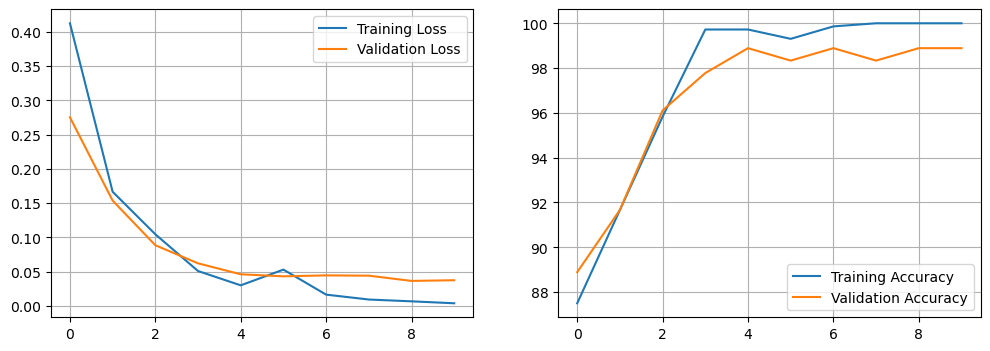


Test accuracy: 98.89%


In [27]:
# Plot the training and validation losses
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.grid()

# Plot the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(100.*np.array(train_acc), label='Training Accuracy')
plt.plot(100.*np.array(val_acc), label='Validation Accuracy')
plt.legend()
plt.grid()

plt.show()

# Print out final test accuracy
print('\nTest accuracy: %.2f%%' % (100.*val_acc[-1]))

### Take away after first tries:

Test accuracy of 98.33% is pretty good. At Epoch 4 we can see a slight overfit, since the training and validation loss curves split apart.

What we can adjust to try avoiding this:
- Integrate an early dropout
- Learning Rate reduction if validation reaches a plateau (LR Scheduler)